# Research Question 2

_How do unification approaches of ML and LLMs perform in terms of forecasting the binary incidence of psychological disorders?_

**Evaluation and comparison of unification approaches**:

**Unification Approaches:**
- Creation of new input data for ML models
- Proportion of Votes (PoV)
- OR Unification of best LLMs and best ML models

# 0 Imports

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, recall_score, matthews_corrcoef, accuracy_score, auc, roc_curve
from sklearn.model_selection import train_test_split

In [38]:
data_change = pd.read_csv("../dat/dips/DIPS_Data_cleaned_change.csv", sep = ",", low_memory = False)

## Unification Approaches

#### Creation of new input data for ML models

In [39]:
y_pred_new_input_nb = pd.read_csv("03_Unification/y_pred_unification/new_input/y_pred_new_input_nb.csv", sep =",")

#### Proportion of Votes (PoV)

In [40]:
y_pred_pov_all_models = pd.read_csv("03_Unification/y_pred_unification/proportion_of_votes/y_pred_pov_all_models.csv", sep =",")
y_pred_pov_ml_votes = pd.read_csv("03_Unification/y_pred_unification/proportion_of_votes/y_pred_pov_ml_models.csv", sep =",")
y_pred_pov_llm_votes = pd.read_csv("03_Unification/y_pred_unification/proportion_of_votes/y_pred_pov_llm_models.csv", sep =",")
y_pred_pov_simple_votes = pd.read_csv(
    "03_Unification/y_pred_unification/proportion_of_votes/y_pred_pov_simple_models.csv", sep =",")
y_pred_pov_class_definitions_votes = pd.read_csv(
    "03_Unification/y_pred_unification/proportion_of_votes/y_pred_pov_class_definitions_models.csv", sep =",")
y_pred_pov_profiled_simple_votes = pd.read_csv(
    "03_Unification/y_pred_unification/proportion_of_votes/y_pred_pov_profiled_simple_models.csv", sep =",")
y_pred_pov_few_shot_votes = pd.read_csv(
    "03_Unification/y_pred_unification/proportion_of_votes/y_pred_pov_few_shot_models.csv", sep =",")
y_pred_pov_vignette_votes = pd.read_csv(
    "03_Unification/y_pred_unification/proportion_of_votes/y_pred_pov_vignette_models.csv", sep =",")
y_pred_pov_cot_votes = pd.read_csv("03_Unification/y_pred_unification/proportion_of_votes/y_pred_pov_cot_models.csv", sep =",")

#### OR Unification of best LLMs and best ML models

In [41]:
y_pred_best_LLM_or_best_ML = pd.read_csv(
    "03_Unification/y_pred_unification/OR_unification/y_pred_best_LLM_or_best_ML.csv", sep =",")

# 1 Metrics

In [42]:
# Predictors
X = data_change
X = X.drop(["hpi"], axis = 1)

# Target
y = data_change["hpi"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

print("X_train shape: ", X_train.shape, round(X_train.shape[0]/len(X), 2), "\n",
      "X_test shape: ", X_test.shape, round(X_test.shape[0]/len(X), 2),  "\n",
      "y_train shape: ", y_train.shape, round(y_train.shape[0]/len(y), 2), "\n",
      "y_test shape: ", y_test.shape, round(y_test.shape[0]/len(y), 2), "\n")

X_train shape:  (983, 22) 0.8 
 X_test shape:  (246, 22) 0.2 
 y_train shape:  (983,) 0.8 
 y_test shape:  (246,) 0.2 



In [43]:
# calculate metrics for all models
def calculate_metrics(y_test, y_pred):
    accuracy = accuracy_score(y_test, y_pred)
    macro_f1 = recall_score(y_test, y_pred, average = "macro")
    micro_f1 = recall_score(y_test, y_pred, average = "micro")
    mcc = matthews_corrcoef(y_test, y_pred)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel().tolist()

    specificity = tn / (tn + fp)
    sensitivity = tp / (tp + fn)

    recall = tp / (tp + fn)
    precision = tp / (tp + fp)

    fpr, tpr, thresholds = roc_curve(y_test, y_pred, pos_label = 1)
    roc_auc = auc(fpr, tpr)

    # dictionary with all metrics
    metrics = {
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "micro_f1": micro_f1,
        "mcc": mcc,
        "precision": precision,
        "recall": recall,
        "sensitivity": sensitivity,
        "specificity": specificity,
        "roc_auc": roc_auc
    }

    return metrics

## Metrics: Unification Approaches

In [44]:
metrics_new_input_nb = calculate_metrics(y_test, y_pred_new_input_nb["y_pred"])

In [45]:
metrics_pov_all_models = calculate_metrics(y_test, y_pred_pov_all_models["y_pred"])
metrics_pov_ml_votes = calculate_metrics(y_test, y_pred_pov_ml_votes["y_pred"])
metrics_pov_llm_votes = calculate_metrics(y_test, y_pred_pov_llm_votes["y_pred"])
metrics_pov_simple_votes = calculate_metrics(y_test, y_pred_pov_simple_votes["y_pred"])
metrics_pov_class_definitions_votes = calculate_metrics(y_test, y_pred_pov_class_definitions_votes["y_pred"])
metrics_pov_profiled_simple_votes = calculate_metrics(y_test, y_pred_pov_profiled_simple_votes["y_pred"])
metrics_pov_few_shot_votes = calculate_metrics(y_test, y_pred_pov_few_shot_votes["y_pred"])
metrics_pov_vignette_votes = calculate_metrics(y_test, y_pred_pov_vignette_votes["y_pred"])
metrics_pov_cot_votes = calculate_metrics(y_test, y_pred_pov_cot_votes["y_pred"])

In [46]:
metrics_best_LLM_or_best_ML = calculate_metrics(y_test, y_pred_best_LLM_or_best_ML["y_pred"])

# 2 Visualize Metrics

In [47]:
LLM_colors = [
    "#6F8F00", #GPT green
    "#CCB900", #Gemini yellow
    "#7EB5D6", #Gemma blue
    "#A51E37", #Claude red
    "#4A36C2", #DeepSeek purple
    "#EB7801", #Grok orange
]

ML_colors = [
    "#C3C3C3", # Logistic Regression grey
    "#875A00", # Random Forest brown
    "#076300", # Support Vector Machine dark green
    "#CF3400", # Deep Neural red
    "#03588C", # Naive Bayes blue
    "#8F00A8" # K-Nearest Neighbors purple
]

## Unification Approaches

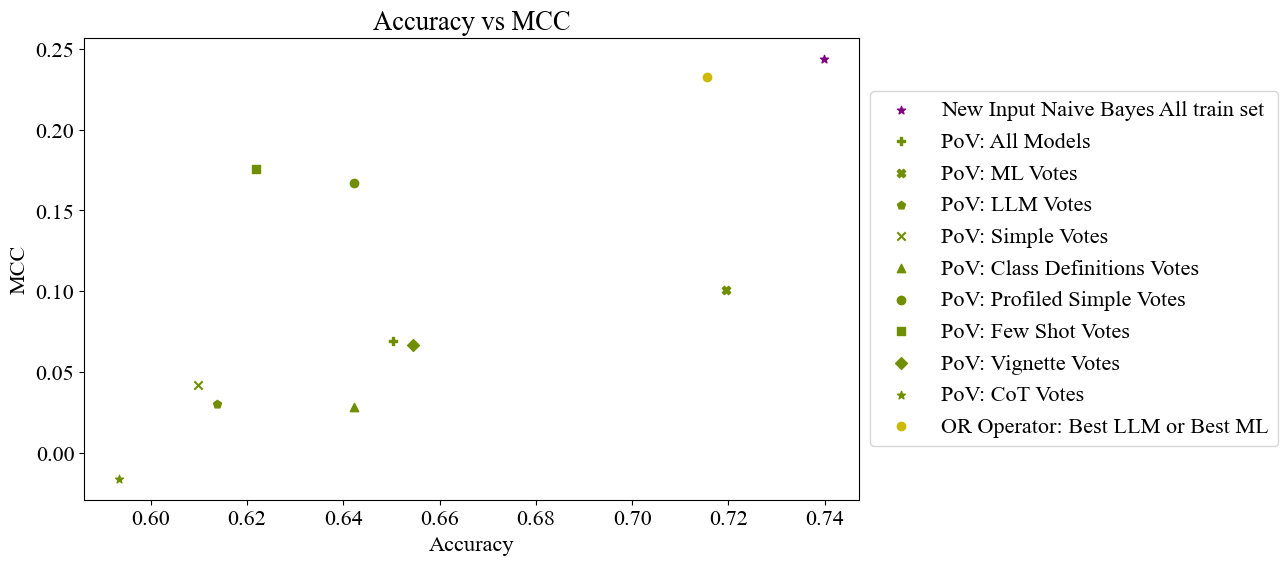

In [51]:
# plot all unification approaches: MCC vs Accuracy
plt.figure(figsize = (10, 6))

plt.scatter(metrics_new_input_nb["accuracy"], metrics_new_input_nb["mcc"], label = "New Input Naive Bayes All train set", color = "purple", marker = "*")

plt.scatter(metrics_pov_all_models["accuracy"], metrics_pov_all_models["mcc"], label = "PoV: All Models", color = LLM_colors[0], marker = "P")
plt.scatter(metrics_pov_ml_votes["accuracy"], metrics_pov_ml_votes["mcc"], label = "PoV: ML Votes", color = LLM_colors[0], marker = "X")
plt.scatter(metrics_pov_llm_votes["accuracy"], metrics_pov_llm_votes["mcc"], label = "PoV: LLM Votes", color = LLM_colors[0], marker = "p")
plt.scatter(metrics_pov_simple_votes["accuracy"], metrics_pov_simple_votes["mcc"], label = "PoV: Simple Votes", color = LLM_colors[0], marker = "x")
plt.scatter(metrics_pov_class_definitions_votes["accuracy"], metrics_pov_class_definitions_votes["mcc"], label = "PoV: Class Definitions Votes", color = LLM_colors[0], marker = "^")
plt.scatter(metrics_pov_profiled_simple_votes["accuracy"], metrics_pov_profiled_simple_votes["mcc"], label = "PoV: Profiled Simple Votes", color = LLM_colors[0], marker = "o")
plt.scatter(metrics_pov_few_shot_votes["accuracy"], metrics_pov_few_shot_votes["mcc"], label = "PoV: Few Shot Votes", color = LLM_colors[0], marker = "s")
plt.scatter(metrics_pov_vignette_votes["accuracy"], metrics_pov_vignette_votes["mcc"], label = "PoV: Vignette Votes", color = LLM_colors[0], marker = "D")
plt.scatter(metrics_pov_cot_votes["accuracy"], metrics_pov_cot_votes["mcc"], label = "PoV: CoT Votes", color = LLM_colors[0], marker = "*")

plt.scatter(metrics_best_LLM_or_best_ML["accuracy"], metrics_best_LLM_or_best_ML["mcc"], label = "OR Operator: Best LLM or Best ML", color = LLM_colors[1], marker = "o")

plt.xlabel("Accuracy")
plt.ylabel("MCC")
plt.title("Accuracy vs MCC")
plt.legend(loc = 'center left', bbox_to_anchor = (1, 0.5))
# plt.grid()

# # save as png
plt.savefig("../doc/figs/02_unification_performance/accuracy_mcc_unification.png", dpi = 300, bbox_inches = "tight")

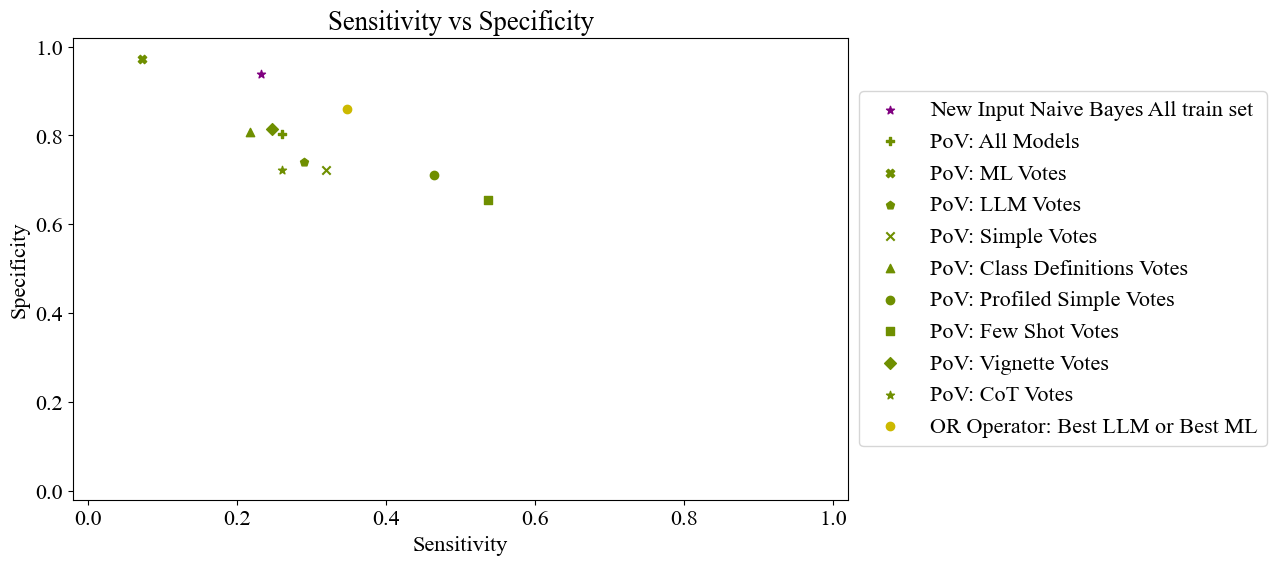

In [52]:
# plot sensitivity vs specificity for all unification approaches
plt.figure(figsize = (10, 6))

plt.scatter(metrics_new_input_nb["sensitivity"], metrics_new_input_nb["specificity"], label = "New Input Naive Bayes All train set", color = "purple", marker = "*")

plt.scatter(metrics_pov_all_models["sensitivity"], metrics_pov_all_models["specificity"], label = "PoV: All Models", color = LLM_colors[0], marker = "P")
plt.scatter(metrics_pov_ml_votes["sensitivity"], metrics_pov_ml_votes["specificity"], label = "PoV: ML Votes", color = LLM_colors[0], marker = "X")
plt.scatter(metrics_pov_llm_votes["sensitivity"], metrics_pov_llm_votes["specificity"], label = "PoV: LLM Votes", color = LLM_colors[0], marker = "p")
plt.scatter(metrics_pov_simple_votes["sensitivity"], metrics_pov_simple_votes["specificity"], label = "PoV: Simple Votes", color = LLM_colors[0], marker = "x")
plt.scatter(metrics_pov_class_definitions_votes["sensitivity"], metrics_pov_class_definitions_votes["specificity"], label = "PoV: Class Definitions Votes", color = LLM_colors[0], marker = "^")
plt.scatter(metrics_pov_profiled_simple_votes["sensitivity"], metrics_pov_profiled_simple_votes["specificity"], label = "PoV: Profiled Simple Votes", color = LLM_colors[0], marker = "o")
plt.scatter(metrics_pov_few_shot_votes["sensitivity"], metrics_pov_few_shot_votes["specificity"], label = "PoV: Few Shot Votes", color = LLM_colors[0], marker = "s")
plt.scatter(metrics_pov_vignette_votes["sensitivity"], metrics_pov_vignette_votes["specificity"], label = "PoV: Vignette Votes", color = LLM_colors[0], marker = "D")
plt.scatter(metrics_pov_cot_votes["sensitivity"], metrics_pov_cot_votes["specificity"], label = "PoV: CoT Votes", color = LLM_colors[0], marker = "*")

plt.scatter(metrics_best_LLM_or_best_ML["sensitivity"], metrics_best_LLM_or_best_ML["specificity"], label = "OR Operator: Best LLM or Best ML", color = LLM_colors[1], marker = "o")

plt.xlim(-0.02, 1.02)
plt.ylim(-0.02, 1.02)

plt.xlabel("Sensitivity")
plt.ylabel("Specificity")
plt.title("Sensitivity vs Specificity")
plt.legend(loc = 'center left', bbox_to_anchor = (1, 0.5))
# plt.grid()

# # save as png
plt.savefig("../doc/figs/02_unification_performance/sensitivity_specificity_unification.png", dpi = 300, bbox_inches = "tight")

# 3 Print metrics

## Unification Approaches

In [50]:
print(f"""Metrics for all Unification Approaches:

Method | Accuracy | MCC | Sensitivity | Specificity | Precision | F1 |
New Input NB   | {round(metrics_new_input_nb["accuracy"], 2)} | {round(metrics_new_input_nb["mcc"], 2)} | {round(metrics_new_input_nb["sensitivity"], 2)} | {round(metrics_new_input_nb["specificity"], 2)} | {round(metrics_new_input_nb["precision"], 2)} | {round(metrics_new_input_nb["macro_f1"], 2)}
POV: All       | {round(metrics_pov_all_models["accuracy"], 2)} | {round(metrics_pov_all_models["mcc"], 2)} | {round(metrics_pov_all_models["sensitivity"], 2)} | {round(metrics_pov_all_models["specificity"], 2)} | {round(metrics_pov_all_models["precision"], 2)} | {round(metrics_pov_all_models["macro_f1"], 2)}
POV: ML        | {round(metrics_pov_ml_votes["accuracy"], 2)} | {round(metrics_pov_ml_votes["mcc"], 2)} | {round(metrics_pov_ml_votes["sensitivity"], 2)} | {round(metrics_pov_ml_votes["specificity"], 2)} | {round(metrics_pov_ml_votes["precision"], 2)} | {round(metrics_pov_ml_votes["macro_f1"], 2)}
POV: LLMs      | {round(metrics_pov_llm_votes["accuracy"], 2)} | {round(metrics_pov_llm_votes["mcc"], 2)} | {round(metrics_pov_llm_votes["sensitivity"], 2)} | {round(metrics_pov_llm_votes["specificity"], 2)} | {round(metrics_pov_llm_votes["precision"], 2)} | {round(metrics_pov_llm_votes["macro_f1"], 2)}
POV: Simple    | {round(metrics_pov_simple_votes["accuracy"], 2)} | {round(metrics_pov_simple_votes["mcc"], 2)} | {round(metrics_pov_simple_votes["sensitivity"], 2)} | {round(metrics_pov_simple_votes["specificity"], 2)} | {round(metrics_pov_simple_votes["precision"], 2)} | {round(metrics_pov_simple_votes["macro_f1"], 2)}
POV: Class Def | {round(metrics_pov_class_definitions_votes["accuracy"], 2)} | {round(metrics_pov_class_definitions_votes["mcc"], 2)} | {round(metrics_pov_class_definitions_votes["sensitivity"], 2)} | {round(metrics_pov_class_definitions_votes["specificity"], 2)} | {round(metrics_pov_class_definitions_votes["precision"], 2)} | {round(metrics_pov_class_definitions_votes["macro_f1"], 2)}
POV: Profiled  | {round(metrics_pov_profiled_simple_votes["accuracy"], 2)} | {round(metrics_pov_profiled_simple_votes["mcc"], 2)} | {round(metrics_pov_profiled_simple_votes["sensitivity"], 2)} | {round(metrics_pov_profiled_simple_votes["specificity"], 2)} | {round(metrics_pov_profiled_simple_votes["precision"], 2)} | {round(metrics_pov_profiled_simple_votes["macro_f1"], 2)}
POV: Few Shot  | {round(metrics_pov_few_shot_votes["accuracy"], 2)} | {round(metrics_pov_few_shot_votes["mcc"], 2)} | {round(metrics_pov_few_shot_votes["sensitivity"], 2)} | {round(metrics_pov_few_shot_votes["specificity"], 2)} | {round(metrics_pov_few_shot_votes["precision"], 2)} | {round(metrics_pov_few_shot_votes["macro_f1"], 2)}
POV: Vignette  | {round(metrics_pov_vignette_votes["accuracy"], 2)} | {round(metrics_pov_vignette_votes["mcc"], 2)} | {round(metrics_pov_vignette_votes["sensitivity"], 2)} | {round(metrics_pov_vignette_votes["specificity"], 2)} | {round(metrics_pov_vignette_votes["precision"], 2)} | {round(metrics_pov_vignette_votes["macro_f1"], 2)}
POV: CoT       | {round(metrics_pov_cot_votes["accuracy"], 2)} | {round(metrics_pov_cot_votes["mcc"], 2)} | {round(metrics_pov_cot_votes["sensitivity"], 2)} | {round(metrics_pov_cot_votes["specificity"], 2)} | {round(metrics_pov_cot_votes["precision"], 2)} | {round(metrics_pov_cot_votes["macro_f1"], 2)}
Best ML OR LLM | {round(metrics_best_LLM_or_best_ML["accuracy"], 2)} | {round(metrics_best_LLM_or_best_ML["mcc"], 2)} | {round(metrics_best_LLM_or_best_ML["sensitivity"], 2)} | {round(metrics_best_LLM_or_best_ML["specificity"], 2)} | {round(metrics_best_LLM_or_best_ML["precision"], 2)} | {round(metrics_best_LLM_or_best_ML["macro_f1"], 2)}
""")

Metrics for all Unification Approaches:

Method | Accuracy | MCC | Sensitivity | Specificity | Precision | F1 |
New Input NB   | 0.74 | 0.24 | 0.23 | 0.94 | 0.59 | 0.58
POV: All       | 0.65 | 0.07 | 0.26 | 0.8 | 0.34 | 0.53
POV: ML        | 0.72 | 0.1 | 0.07 | 0.97 | 0.5 | 0.52
POV: LLMs      | 0.61 | 0.03 | 0.29 | 0.74 | 0.3 | 0.51
POV: Simple    | 0.61 | 0.04 | 0.32 | 0.72 | 0.31 | 0.52
POV: Class Def | 0.64 | 0.03 | 0.22 | 0.81 | 0.31 | 0.51
POV: Profiled  | 0.64 | 0.17 | 0.46 | 0.71 | 0.39 | 0.59
POV: Few Shot  | 0.62 | 0.18 | 0.54 | 0.66 | 0.38 | 0.6
POV: Vignette  | 0.65 | 0.07 | 0.25 | 0.81 | 0.34 | 0.53
POV: CoT       | 0.59 | -0.02 | 0.26 | 0.72 | 0.27 | 0.49
Best ML OR LLM | 0.72 | 0.23 | 0.35 | 0.86 | 0.49 | 0.6

